In [ ]:

import os
import random
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")


Device : cuda
PyTorch: 2.10.0+cu128
GPU    : Tesla T4



Hyperparameters

In [ ]:
# Hyperparams

BATCH_SIZE      = 128
NUM_CLASSES     = 10
IMG_SIZE        = 28          


MAX_STEPS       = 12          
HALT_THRESHOLD  = 0.99        
HIDDEN_DIM      = 256
FEAT_DIM        = 128


EPOCHS_ACT      = 25
EPOCHS_BASE     = 25
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
ALPHA           = 0.05        
WARMUP_EPOCHS   = 6           


AUX_WEIGHT      = 0.3         



HALT_BIAS_INIT  = -5.0


NOISE_LEVELS    = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8]
MASK_FRACTION   = 0.3

CLASS_NAMES = [
    'T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot'
]


Data Loading

In [23]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(28, padding=2),
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),
])

train_dataset = FashionMNIST(root='./data', train=True,  download=True, transform=transform_train)
test_dataset  = FashionMNIST(root='./data', train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples : {len(train_dataset):,}")
print(f"Test  samples : {len(test_dataset):,}")
print(f"Batches/epoch : {len(train_loader)}")


Train samples : 60,000
Test  samples : 10,000
Batches/epoch : 469


In [ ]:
class CNNBackbone(nn.Module):
    """Sequential CNN feature extractor — no residual connections."""

    def __init__(self, feat_dim: int = FEAT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 28→14
            nn.Dropout2d(0.1),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),          # 14→7
            nn.Dropout2d(0.1),

            # Block 3
            nn.Conv2d(64, feat_dim, kernel_size=3, padding=1),
            nn.BatchNorm2d(feat_dim),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),     # →[B, feat_dim, 1, 1]
        )

    def forward(self, x):
        return self.net(x).flatten(1)    # [B, feat_dim]


class ACTProcessingBlock(nn.Module):
    

    def __init__(self, feat_dim: int, hidden_dim: int, num_classes: int):
        super().__init__()
        self.transform = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feat_dim),
            nn.LayerNorm(feat_dim),
        )
        self.halt_head  = nn.Linear(feat_dim, 1)
        self.class_head = nn.Linear(feat_dim, num_classes)

       
        nn.init.constant_(self.halt_head.bias, HALT_BIAS_INIT)

    def forward(self, h):
       
        h_new     = h + self.transform(h)                    
        halt_prob = torch.sigmoid(self.halt_head(h_new))     
        logits    = self.class_head(h_new)                   
        return h_new, halt_prob.squeeze(-1), logits


class ACTModel(nn.Module):
   

    def __init__(
        self,
        feat_dim:    int   = FEAT_DIM,
        hidden_dim:  int   = HIDDEN_DIM,
        num_classes: int   = NUM_CLASSES,
        max_steps:   int   = MAX_STEPS,
        threshold:   float = HALT_THRESHOLD,
    ):
        super().__init__()
        self.max_steps   = max_steps
        self.threshold   = threshold
        self.num_classes = num_classes

        self.backbone = CNNBackbone(feat_dim)
        self.block    = ACTProcessingBlock(feat_dim, hidden_dim, num_classes)

    def forward(self, x):
        B = x.size(0)

        h = self.backbone(x)                                        

       
        cumulative_halt  = torch.zeros(B, device=x.device)
        halted           = torch.zeros(B, dtype=torch.bool, device=x.device)
        steps_taken      = torch.zeros(B, dtype=torch.long, device=x.device)
        weighted_logits  = torch.zeros(B, self.num_classes, device=x.device)

        
        halt_remainders  = torch.ones(B, device=x.device)

        per_step_logits  = []    
        all_halt_probs   = []

        for t in range(self.max_steps):
            h_new, p_t, logits_t = self.block(h)
            all_halt_probs.append(p_t.detach())
            per_step_logits.append(logits_t)

            
            current_remainder = (1.0 - cumulative_halt).clamp(min=0.0)

            
            last_step = (t == self.max_steps - 1)
            will_halt = (cumulative_halt + p_t >= self.threshold) | last_step
            halt_now  = will_halt & ~halted

            
            weight = torch.where(halt_now, current_remainder, p_t)
            weighted_logits = weighted_logits + weight.unsqueeze(-1) * logits_t

            
            halt_remainders = torch.where(halt_now, current_remainder, halt_remainders)

            
            cumulative_halt = torch.where(~halted, cumulative_halt + p_t, cumulative_halt)
            steps_taken     = torch.where(halt_now, torch.full_like(steps_taken, t + 1), steps_taken)
            halted          = halted | halt_now
            h               = h_new

            if halted.all():
                break

       
        ponder_cost = steps_taken.float().detach() + halt_remainders

        return weighted_logits, ponder_cost, steps_taken, all_halt_probs, per_step_logits


class VanillaModel(nn.Module):
    """Same CNN backbone + fixed-depth classifier head. No ACT."""

    def __init__(self, feat_dim: int = FEAT_DIM, hidden_dim: int = HIDDEN_DIM, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.backbone   = CNNBackbone(feat_dim)
        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, feat_dim),
            nn.LayerNorm(feat_dim),
            nn.GELU(),
            nn.Linear(feat_dim, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

_dummy     = torch.randn(4, 1, 28, 28)
act_model  = ACTModel().to(DEVICE)
base_model = VanillaModel().to(DEVICE)

with torch.no_grad():
    logits, ponder, steps, hps, psl = act_model(_dummy.to(DEVICE))
    bl = base_model(_dummy.to(DEVICE))

print(f"ACT   params       : {count_params(act_model):,}")
print(f"Vanilla params     : {count_params(base_model):,}")
print(f"ACT output shape   : {logits.shape}")
print(f"Ponder cost (init) : {ponder.detach().cpu().numpy().round(3)}")
print(f"Steps taken (init) : {steps.cpu().numpy()}")
print(f"  → Should be {MAX_STEPS} (all max) at init due to negative halt bias")
print(f"  → Ponder cost should be ~{MAX_STEPS + 1:.0f} (N + R where R≈1 at start)")


ACT   params       : 207,595
Vanilla params     : 207,466
ACT output shape   : torch.Size([4, 10])
Ponder cost (init) : [12.988 12.99  12.992 12.989]
Steps taken (init) : [12 12 12 12]
  → Should be 12 (all max) at init due to negative halt bias
  → Ponder cost should be ~13 (N + R where R≈1 at start)


Loss Function

In [ ]:
def get_alpha(epoch: int) -> float:
   
    if epoch <= WARMUP_EPOCHS:
        return 0.0
    ramp = min(1.0, (epoch - WARMUP_EPOCHS) / 5.0)
    return ALPHA * ramp


def act_loss(logits, targets, ponder_cost, per_step_logits, alpha=ALPHA, aux_weight=AUX_WEIGHT):
    
    ce   = F.cross_entropy(logits, targets)
    pond = alpha * ponder_cost.mean()

    # Auxiliary loss: CE at every intermediate step
    if aux_weight > 0 and len(per_step_logits) > 0:
        aux_losses = [F.cross_entropy(sl, targets) for sl in per_step_logits]
        aux = aux_weight * sum(aux_losses) / len(aux_losses)
    else:
        aux = torch.tensor(0.0, device=logits.device)

    return ce + pond + aux, ce.item(), pond.item(), aux.item()


def train_epoch_act(model, loader, optimizer, epoch, scheduler=None):
    model.train()
    total_loss, total_ce, total_pond, total_aux = 0.0, 0.0, 0.0, 0.0
    correct, n_samples = 0, 0
    all_steps = []

    alpha = get_alpha(epoch)

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        logits, ponder, steps, _, per_step_logits = model(imgs)
        loss, ce, pond, aux = act_loss(logits, labels, ponder, per_step_logits, alpha=alpha)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler: scheduler.step()

        bs = imgs.size(0)
        total_loss += loss.item() * bs
        total_ce   += ce          * bs
        total_pond += pond        * bs
        total_aux  += aux         * bs
        correct    += (logits.argmax(1) == labels).sum().item()
        n_samples  += bs
        all_steps.extend(steps.cpu().tolist())

    step_arr = np.array(all_steps)
    return {
        'loss'     : total_loss / n_samples,
        'ce'       : total_ce   / n_samples,
        'pond'     : total_pond / n_samples,
        'aux'      : total_aux  / n_samples,
        'acc'      : correct / n_samples,
        'steps'    : step_arr.mean(),
        'step_std' : step_arr.std(),    
        'alpha'    : alpha,
    }


@torch.no_grad()
def eval_act(model, loader):
    model.eval()
    correct, n_samples = 0, 0
    all_steps, all_ponder = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits, ponder, steps, _, _ = model(imgs)
        correct    += (logits.argmax(1) == labels).sum().item()
        n_samples  += imgs.size(0)
        all_steps.extend(steps.cpu().tolist())
        all_ponder.extend(ponder.cpu().tolist())

    step_arr = np.array(all_steps)
    return {
        'acc'      : correct / n_samples,
        'steps'    : step_arr.mean(),
        'step_std' : step_arr.std(),
        'ponder'   : np.mean(all_ponder),
    }


def train_epoch_vanilla(model, loader, optimizer, scheduler=None):
    model.train()
    total_loss, correct, n_samples = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = F.cross_entropy(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n_samples  += imgs.size(0)
    return {'loss': total_loss / n_samples, 'acc': correct / n_samples}


@torch.no_grad()
def eval_vanilla(model, loader):
    model.eval()
    correct, n_samples = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits    = model(imgs)
        correct   += (logits.argmax(1) == labels).sum().item()
        n_samples += imgs.size(0)
    return correct / n_samples


print("Training utilities ready.")
print(f"Alpha schedule: 0.0 for epochs 1–{WARMUP_EPOCHS}, ramps to {ALPHA} by epoch {WARMUP_EPOCHS+5}")


Training utilities ready.
Alpha schedule: 0.0 for epochs 1–6, ramps to 0.05 by epoch 11


 Train ACT Model

In [26]:
act_model = ACTModel(
    feat_dim=FEAT_DIM, hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES, max_steps=MAX_STEPS, threshold=HALT_THRESHOLD
).to(DEVICE)

optimizer_act = optim.AdamW(act_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_act = optim.lr_scheduler.CosineAnnealingLR(optimizer_act, T_max=EPOCHS_ACT)

act_history = defaultdict(list)

print(f"{"Ep":>3} {"α":>6} {"Loss":>8} {"Acc":>8} {"ValAcc":>7} {"Steps":>7} {"StdSteps":>9} {"Pond":>8}")
print("-" * 66)

for epoch in range(1, EPOCHS_ACT + 1):
    tr  = train_epoch_act(act_model, train_loader, optimizer_act, epoch)
    val = eval_act(act_model, test_loader)
    scheduler_act.step()

    for k, v in tr.items():  act_history[f'train_{k}'].append(v)
    for k, v in val.items(): act_history[f'val_{k}'].append(v)

    warmup_marker = " [warmup]" if tr['alpha'] == 0 else ""
    print(f"{epoch:3d} {tr['alpha']:6.3f} {tr['loss']:8.4f} {tr['acc']*100:7.2f}% "
          f"{val['acc']*100:6.2f}%  {val['steps']:6.2f}  ±{val['step_std']:6.2f}  "
          f"{tr['pond']:8.5f}{warmup_marker}")

print("\nACT training complete.")
print(f"Final avg steps : {act_history['val_steps'][-1]:.2f} ± {act_history['val_step_std'][-1]:.2f}")
print(f"  → Non-zero std = adaptive behavior confirmed" if act_history['val_step_std'][-1] > 0.3
      else f"  → ⚠ Low std: model not yet fully adaptive; consider tuning ALPHA or HALT_BIAS_INIT")


 Ep      α     Loss      Acc  ValAcc   Steps  StdSteps     Pond
------------------------------------------------------------------
  1  0.000   1.1448   70.58%  79.75%    5.43  ±  4.50   0.00000 [warmup]
  2  0.000   0.6029   83.39%  85.74%    9.13  ±  4.45   0.00000 [warmup]
  3  0.000   0.4937   86.47%  88.41%    6.94  ±  4.84   0.00000 [warmup]
  4  0.000   0.4351   88.06%  88.31%    3.69  ±  3.72   0.00000 [warmup]
  5  0.000   0.4056   88.80%  90.21%    6.23  ±  4.87   0.00000 [warmup]
  6  0.000   0.3782   89.55%  90.93%    6.88  ±  4.96   0.00000 [warmup]
  7  0.010   0.3848   90.03%  90.80%    2.00  ±  0.01   0.02747
  8  0.020   0.3841   90.51%  91.46%    3.10  ±  3.14   0.04439
  9  0.030   0.4156   91.05%  91.23%    3.00  ±  3.39   0.08935
 10  0.040   0.4153   91.47%  91.87%    1.63  ±  1.76   0.10851
 11  0.050   0.4154   91.72%  92.01%    2.51  ±  3.46   0.11989
 12  0.050   0.4037   92.01%  92.22%    1.80  ±  2.44   0.11709
 13  0.050   0.3923   92.39%  91.82%    1.60  ±

 Train Vanilla Baseline

In [27]:
base_model = VanillaModel(FEAT_DIM, HIDDEN_DIM, NUM_CLASSES).to(DEVICE)

optimizer_base = optim.AdamW(base_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler_base = optim.lr_scheduler.CosineAnnealingLR(optimizer_base, T_max=EPOCHS_BASE)

base_history = defaultdict(list)

print(f"{"Ep":>3} {"TrainLoss":>10} {"TrainAcc":>9} {"TestAcc":>8}")
print("-" * 35)

for epoch in range(1, EPOCHS_BASE + 1):
    tr   = train_epoch_vanilla(base_model, train_loader, optimizer_base)
    vacc = eval_vanilla(base_model, test_loader)
    scheduler_base.step()

    base_history['train_loss'].append(tr['loss'])
    base_history['train_acc'].append(tr['acc'])
    base_history['val_acc'].append(vacc)

    print(f"{epoch:3d} {tr['loss']:10.4f} {tr['acc']*100:8.2f}% {vacc*100:7.2f}%")

print("\nBaseline training complete.")


 Ep  TrainLoss  TrainAcc  TestAcc
-----------------------------------
  1     0.6850    74.26%   82.79%
  2     0.4273    84.12%   87.02%
  3     0.3617    86.85%   87.30%
  4     0.3275    87.97%   88.47%
  5     0.3036    88.91%   88.45%
  6     0.2808    89.75%   90.10%
  7     0.2663    90.21%   90.68%
  8     0.2561    90.63%   91.15%
  9     0.2421    91.13%   91.84%
 10     0.2340    91.43%   91.27%
 11     0.2239    91.70%   91.96%
 12     0.2155    92.17%   92.22%
 13     0.2082    92.40%   92.40%
 14     0.2012    92.59%   92.44%
 15     0.1937    92.98%   92.51%
 16     0.1888    93.09%   93.10%
 17     0.1854    93.15%   92.90%
 18     0.1774    93.42%   93.01%
 19     0.1747    93.52%   93.15%
 20     0.1682    93.90%   93.28%
 21     0.1636    93.98%   93.24%
 22     0.1611    94.06%   93.25%
 23     0.1604    94.10%   93.34%
 24     0.1574    94.24%   93.42%
 25     0.1572    94.19%   93.37%

Baseline training complete.


 Corruption 

In [28]:
def add_gaussian_noise(imgs: torch.Tensor, sigma: float) -> torch.Tensor:
    return imgs + sigma * torch.randn_like(imgs)


def add_random_mask(imgs: torch.Tensor, mask_frac: float = MASK_FRACTION) -> torch.Tensor:
    mask = (torch.rand_like(imgs) > mask_frac).float()
    return imgs * mask


def add_blur(imgs: torch.Tensor, kernel_size: int = 5, sigma: float = 2.0) -> torch.Tensor:
    coords  = torch.arange(kernel_size, dtype=torch.float, device=imgs.device) - kernel_size // 2
    gauss1d = torch.exp(-0.5 * (coords / sigma) ** 2)
    gauss1d /= gauss1d.sum()
    kernel  = gauss1d.unsqueeze(0) * gauss1d.unsqueeze(1)
    kernel  = kernel.unsqueeze(0).unsqueeze(0)
    return F.conv2d(imgs, kernel, padding=kernel_size // 2)


@torch.no_grad()
def eval_act_with_corruption(model, loader, corrupt_fn, *corrupt_args):
    model.eval()
    correct, n_samples, all_steps = 0, 0, []
    for imgs, labels in loader:
        imgs_c = corrupt_fn(imgs.to(DEVICE), *corrupt_args)
        labels = labels.to(DEVICE)
        logits, _, steps, _, _ = model(imgs_c)   # unpack 5-tuple
        correct   += (logits.argmax(1) == labels).sum().item()
        n_samples += imgs.size(0)
        all_steps.extend(steps.cpu().tolist())
    return correct / n_samples, np.mean(all_steps), np.std(all_steps)


@torch.no_grad()
def eval_vanilla_with_corruption(model, loader, corrupt_fn, *corrupt_args):
    model.eval()
    correct, n_samples = 0, 0
    for imgs, labels in loader:
        imgs_c = corrupt_fn(imgs.to(DEVICE), *corrupt_args)
        labels = labels.to(DEVICE)
        logits = model(imgs_c)
        correct   += (logits.argmax(1) == labels).sum().item()
        n_samples += imgs.size(0)
    return correct / n_samples


print("Corruption utilities ready.")


Corruption utilities ready.


In [29]:
results = {'noise': [], 'act_acc': [], 'base_acc': [], 'act_steps': [], 'act_step_std': []}

print(f"{"Noise σ":>8} {"ACT Acc":>9} {"Base Acc":>10} {"ACT Steps":>11} {"StdDev":>8}")
print("-" * 52)

for sigma in NOISE_LEVELS:
    a_acc, a_steps, a_std = eval_act_with_corruption(act_model,  test_loader, add_gaussian_noise, sigma)
    b_acc                 = eval_vanilla_with_corruption(base_model, test_loader, add_gaussian_noise, sigma)

    results['noise'].append(sigma)
    results['act_acc'].append(a_acc)
    results['base_acc'].append(b_acc)
    results['act_steps'].append(a_steps)
    results['act_step_std'].append(a_std)

    print(f"{sigma:8.2f} {a_acc*100:8.2f}%  {b_acc*100:8.2f}%  {a_steps:10.3f}  ±{a_std:6.3f}")

# Verify monotonic step increase
step_diffs = [results['act_steps'][i+1] - results['act_steps'][i]
              for i in range(len(results['act_steps'])-1)]
monotone_pct = 100 * sum(d > 0 for d in step_diffs) / len(step_diffs)
print(f"\nStep monotonicity with noise : {monotone_pct:.0f}% of transitions increase")
print(f"  → 100% = perfect adaptive behaviour; >70% = strong signal")


 Noise σ   ACT Acc   Base Acc   ACT Steps   StdDev
----------------------------------------------------
    0.00    93.49%     93.37%       1.280  ± 1.535
    0.10    85.14%     77.96%       1.327  ± 1.652
    0.20    67.82%     56.32%       1.179  ± 1.234
    0.30    50.63%     40.87%       1.286  ± 1.606
    0.40    38.73%     33.12%       1.674  ± 2.497
    0.50    31.10%     28.51%       2.639  ± 3.759
    0.60    24.98%     24.84%       4.384  ± 4.914
    0.80    16.38%     21.74%       9.152  ± 4.703

Step monotonicity with noise : 86% of transitions increase
  → 100% = perfect adaptive behaviour; >70% = strong signal


 Training Curves

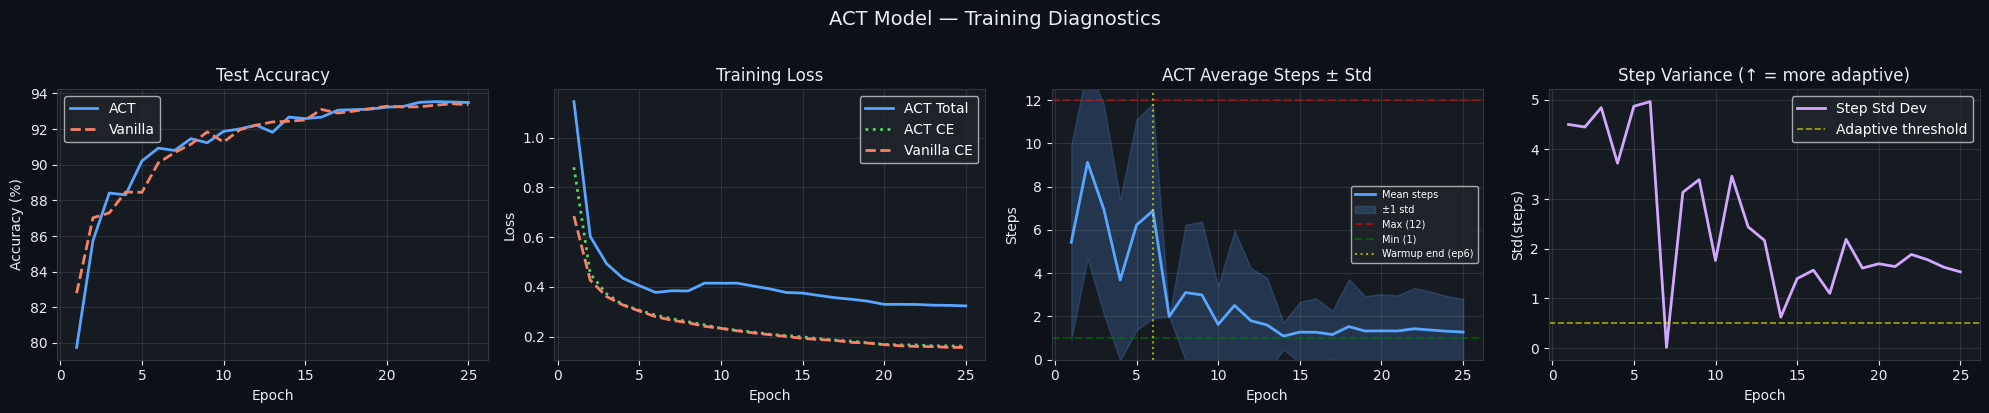

Saved: training_curves.png


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='#e6edf3')
    ax.xaxis.label.set_color('#e6edf3')
    ax.yaxis.label.set_color('#e6edf3')
    ax.title.set_color('#e6edf3')
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

epochs = range(1, EPOCHS_ACT + 1)
CYAN, ORANGE, GREEN, PURPLE = '#58a6ff', '#f78166', '#56d364', '#d2a8ff'

# — Test Accuracy ————————————————————————————————————————————
ax = axes[0]
ax.plot(epochs, [v*100 for v in act_history['val_acc']],  color=CYAN,   lw=2, label='ACT')
ax.plot(epochs, [v*100 for v in base_history['val_acc']], color=ORANGE, lw=2, label='Vanilla', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Test Accuracy'); ax.legend(facecolor='#21262d', labelcolor='white')
ax.grid(True, alpha=0.15)

# — Training Loss ————————————————————————————————————————————
ax = axes[1]
ax.plot(epochs, act_history['train_loss'],  color=CYAN,   lw=2, label='ACT Total')
ax.plot(epochs, act_history['train_ce'],    color=GREEN,  lw=2, label='ACT CE',     linestyle=':')
ax.plot(epochs, base_history['train_loss'], color=ORANGE, lw=2, label='Vanilla CE', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training Loss'); ax.legend(facecolor='#21262d', labelcolor='white')
ax.grid(True, alpha=0.15)

# — Average Steps ————————————————————————————————————————————
ax = axes[2]
ax.plot(epochs, act_history['val_steps'], color=CYAN, lw=2, label='Mean steps')
ax.fill_between(epochs,
    [m - s for m, s in zip(act_history['val_steps'], act_history['val_step_std'])],
    [m + s for m, s in zip(act_history['val_steps'], act_history['val_step_std'])],
    color=CYAN, alpha=0.2, label='±1 std')
ax.axhline(MAX_STEPS, color='red',   linestyle='--', alpha=0.5, label=f'Max ({MAX_STEPS})')
ax.axhline(1.0,       color='green', linestyle='--', alpha=0.5, label='Min (1)')
ax.axvline(WARMUP_EPOCHS, color='yellow', linestyle=':', alpha=0.6, lw=1.5, label=f'Warmup end (ep{WARMUP_EPOCHS})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Steps')
ax.set_title('ACT Average Steps ± Std'); ax.legend(facecolor='#21262d', labelcolor='white', fontsize=7)
ax.grid(True, alpha=0.15); ax.set_ylim(0, MAX_STEPS + 0.5)


ax = axes[3]
ax.plot(epochs, act_history['val_step_std'], color=PURPLE, lw=2, label='Step Std Dev')
ax.axhline(0.5, color='yellow', linestyle='--', alpha=0.6, lw=1.2, label='Adaptive threshold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Std(steps)')
ax.set_title('Step Variance (↑ = more adaptive)')
ax.legend(facecolor='#21262d', labelcolor='white')
ax.grid(True, alpha=0.15)

plt.suptitle('ACT Model — Training Diagnostics', color='#e6edf3', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: training_curves.png")


 Noise vs Steps & Accuracy Visualization

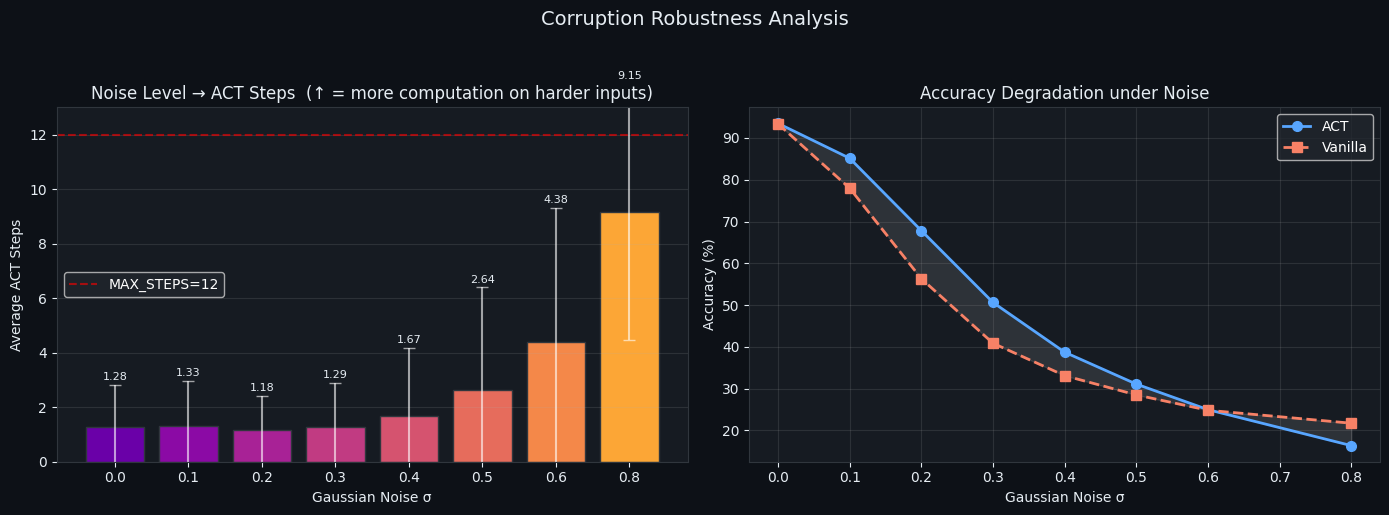

Saved: noise_analysis.png


In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
for ax in (ax1, ax2):
    ax.set_facecolor('#161b22'); ax.tick_params(colors='#e6edf3')
    ax.xaxis.label.set_color('#e6edf3'); ax.yaxis.label.set_color('#e6edf3')
    ax.title.set_color('#e6edf3')
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

noise = results['noise']
color_steps = plt.cm.plasma(np.linspace(0.2, 0.8, len(noise)))

bars = ax1.bar(range(len(noise)), results['act_steps'], color=color_steps, edgecolor='#30363d',
               yerr=results['act_step_std'], capsize=4, error_kw={'ecolor': 'white', 'alpha': 0.6})
ax1.set_xticks(range(len(noise)))
ax1.set_xticklabels([f'{s:.1f}' for s in noise])
ax1.set_xlabel('Gaussian Noise σ'); ax1.set_ylabel('Average ACT Steps')
ax1.set_title('Noise Level → ACT Steps  (↑ = more computation on harder inputs)')
ax1.axhline(MAX_STEPS, color='red', linestyle='--', alpha=0.6, label=f'MAX_STEPS={MAX_STEPS}')
ax1.legend(facecolor='#21262d', labelcolor='white')
ax1.set_ylim(0, MAX_STEPS + 1.0)
ax1.grid(True, axis='y', alpha=0.15)
for bar, val, std in zip(bars, results['act_steps'], results['act_step_std']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.1,
             f'{val:.2f}', ha='center', va='bottom', color='#e6edf3', fontsize=8)

ax2.plot(noise, [v*100 for v in results['act_acc']],  'o-', color='#58a6ff', lw=2, ms=7, label='ACT')
ax2.plot(noise, [v*100 for v in results['base_acc']], 's--', color='#f78166', lw=2, ms=7, label='Vanilla')
ax2.fill_between(noise, [v*100 for v in results['act_acc']], [v*100 for v in results['base_acc']],
    alpha=0.1, color='white')
ax2.set_xlabel('Gaussian Noise σ'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Degradation under Noise')
ax2.legend(facecolor='#21262d', labelcolor='white'); ax2.grid(True, alpha=0.15)

plt.suptitle('Corruption Robustness Analysis', color='#e6edf3', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('noise_analysis.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: noise_analysis.png")


 Per-Class Step Distribution

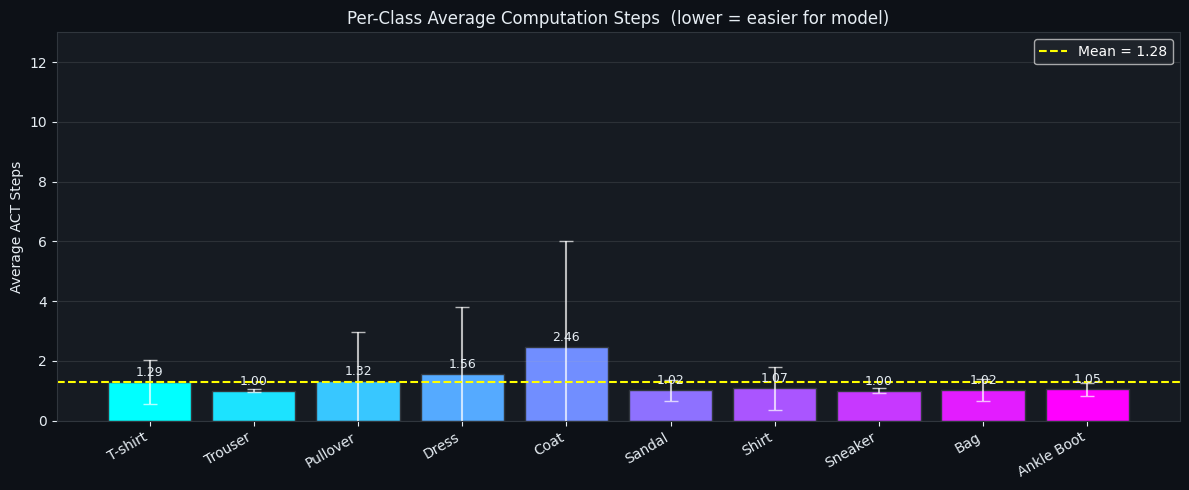

Saved: per_class_steps.png


In [ ]:
@torch.no_grad()
def per_class_steps(model, loader):
    model.eval()
    class_steps = defaultdict(list)
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        _, _, steps, _, _ = model(imgs)   
        for lbl, st in zip(labels.tolist(), steps.cpu().tolist()):
            class_steps[lbl].append(st)
    return {k: (np.mean(v), np.std(v)) for k, v in class_steps.items()}


cls_stats = per_class_steps(act_model, test_loader)
cls_ids   = sorted(cls_stats.keys())
avg_steps = [cls_stats[c][0] for c in cls_ids]
std_steps = [cls_stats[c][1] for c in cls_ids]

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d1117'); ax.set_facecolor('#161b22')
ax.tick_params(colors='#e6edf3')
ax.xaxis.label.set_color('#e6edf3'); ax.yaxis.label.set_color('#e6edf3')
ax.title.set_color('#e6edf3')
for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

colors = plt.cm.cool(np.linspace(0, 1, NUM_CLASSES))
bars   = ax.bar([CLASS_NAMES[c] for c in cls_ids], avg_steps,
                yerr=std_steps, capsize=5, color=colors, edgecolor='#30363d',
                error_kw={'ecolor': 'white', 'alpha': 0.7})
ax.axhline(np.mean(avg_steps), color='yellow', linestyle='--', lw=1.5,
           label=f'Mean = {np.mean(avg_steps):.2f}')
ax.set_ylabel('Average ACT Steps')
ax.set_title('Per-Class Average Computation Steps  (lower = easier for model)')
ax.legend(facecolor='#21262d', labelcolor='white')
ax.set_ylim(0, MAX_STEPS + 1.0); ax.grid(True, axis='y', alpha=0.15)
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, avg_steps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f}', ha='center', va='bottom', color='#e6edf3', fontsize=9)

plt.tight_layout()
plt.savefig('per_class_steps.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: per_class_steps.png")


 Easy vs Hard Sample Deep-Dive

In [ ]:
@torch.no_grad()
def get_sample_details(model, img_tensor, label):
    model.eval()
    img = img_tensor.unsqueeze(0).to(DEVICE)
    logits, ponder, steps, halt_probs, _ = model(img)   
    probs      = F.softmax(logits, dim=-1).squeeze()
    pred       = probs.argmax().item()
    confidence = probs.max().item()
    return {
        'pred'      : pred,
        'true'      : label,
        'conf'      : confidence,
        'steps'     : steps.item(),
        'ponder'    : ponder.item(),
        'halt_probs': [h[0].item() for h in halt_probs],
        'correct'   : pred == label,
    }


act_model.eval()
easy_sample = hard_sample = None

with torch.no_grad():
    for imgs, labels in DataLoader(test_dataset, batch_size=256, shuffle=True):
        imgs_d = imgs.to(DEVICE)
        logits, ponder, steps, _, _ = act_model(imgs_d)
        preds        = logits.argmax(1)
        correct_mask = (preds == labels.to(DEVICE))

        if easy_sample is None:
            valid = correct_mask & (steps == steps[correct_mask].min())
            idx   = valid.nonzero(as_tuple=True)[0]
            if len(idx): easy_sample = (imgs[idx[0].item()], labels[idx[0].item()].item())

        if hard_sample is None:
            valid = correct_mask & (steps == steps[correct_mask].max())
            idx   = valid.nonzero(as_tuple=True)[0]
            if len(idx): hard_sample = (imgs[idx[0].item()], labels[idx[0].item()].item())

        if easy_sample and hard_sample:
            break

easy_d = get_sample_details(act_model, easy_sample[0], easy_sample[1])
hard_d = get_sample_details(act_model, hard_sample[0], hard_sample[1])

corrupt_img = add_gaussian_noise(hard_sample[0].unsqueeze(0).to(DEVICE), sigma=0.4).squeeze(0).cpu()
corrupt_d   = get_sample_details(act_model, corrupt_img, hard_sample[1])


def print_sample_info(title, d):
    print(f"\n{'━'*52}")
    print(f"  {title}")
    print(f"{'━'*52}")
    print(f"  True Label   : {CLASS_NAMES[d['true']]:15s} ({d['true']})")
    print(f"  Prediction   : {CLASS_NAMES[d['pred']]:15s} ({d['pred']})  {'✓' if d['correct'] else '✗'}")
    print(f"  Confidence   : {d['conf']*100:.1f}%")
    print(f"  Steps Taken  : {d['steps']} / {MAX_STEPS}")
    print(f"  Ponder Cost  : {d['ponder']:.4f}  (= {d['steps']} + {d['ponder']-d['steps']:.4f})")
    print(f"  Halting Probs:")
    cumsum = 0.0
    for t, hp in enumerate(d['halt_probs'], 1):
        cumsum += hp
        bar = '█' * int(hp * 30)
        print(f"    Step {t:2d}: p={hp:.4f}  Σ={cumsum:.4f}  {bar}")
        if t == d['steps']:
            print(f"    ──→ HALTED at step {t}")
            break

print_sample_info("EASY SAMPLE (few steps)",     easy_d)
print_sample_info("HARD SAMPLE (many steps)",    hard_d)
print_sample_info("CORRUPTED (+noise σ=0.4)",    corrupt_d)

step_gap = hard_d['steps'] - easy_d['steps']
print(f"\n→ Hard takes {step_gap} more steps than Easy (research signal: hard > easy ✓)")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  EASY SAMPLE (few steps)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  True Label   : Sneaker         (7)
  Prediction   : Sneaker         (7)  ✓
  Confidence   : 60.8%
  Steps Taken  : 1 / 12
  Ponder Cost  : 2.0000  (= 1 + 1.0000)
  Halting Probs:
    Step  1: p=0.9969  Σ=0.9969  █████████████████████████████
    ──→ HALTED at step 1

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  HARD SAMPLE (many steps)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  True Label   : Pullover        (2)
  Prediction   : Pullover        (2)  ✓
  Confidence   : 98.2%
  Steps Taken  : 12 / 12
  Ponder Cost  : 12.0223  (= 12 + 0.0223)
  Halting Probs:
    Step  1: p=0.9720  Σ=0.9720  █████████████████████████████
    Step  2: p=0.0058  Σ=0.9777  
    Step  3: p=0.0000  Σ=0.9777  
    Step  4: p=0.0000  Σ=0.9777  
    Step  5: p=0.0000  Σ=0.9777  
    Step  6: p=0.0000  Σ=0.9777  
    Step  7: p=0.0000  Σ=0.9777  
    Step  8: 

 Visualization with Halting Probability Bars

/tmp/ipykernel_80/427540039.py:48: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('sample_analysis.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
/tmp/ipykernel_80/427540039.py:48: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('sample_analysis.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
/tmp/ipykernel_80/427540039.py:48: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('sample_analysis.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Dej

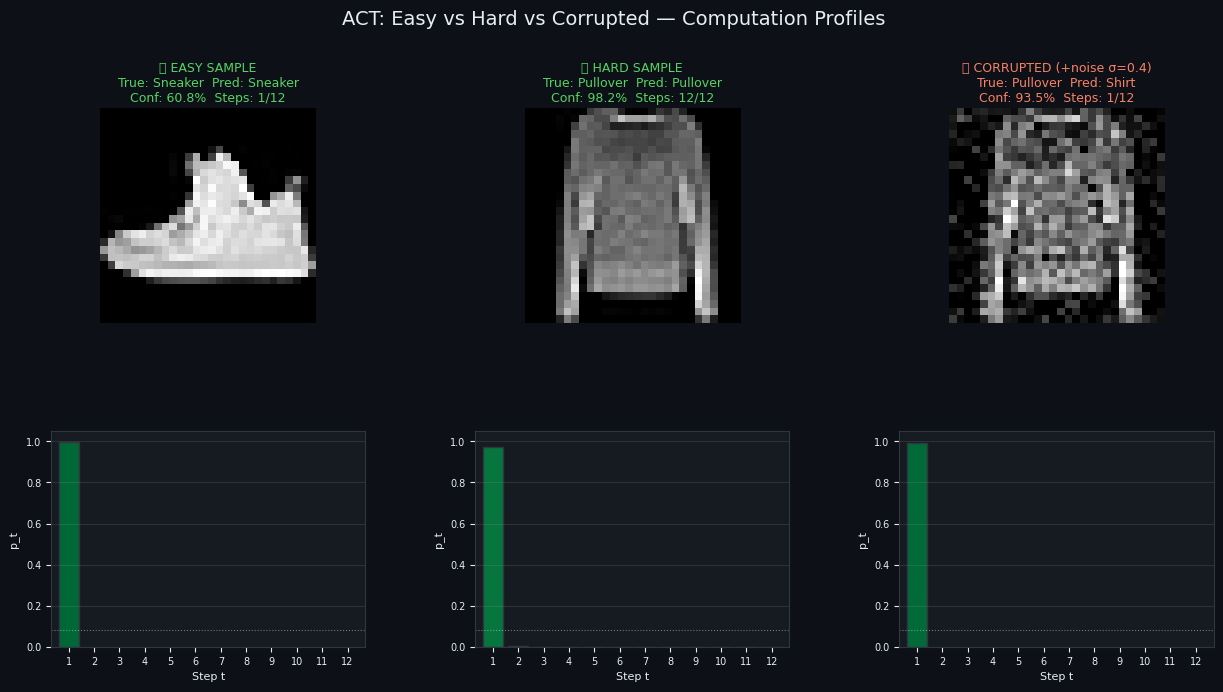

Saved: sample_analysis.png


In [34]:
def denormalize(t):
    return (t * 0.353 + 0.286).clamp(0, 1)


def plot_sample_panel(ax_img, ax_bar, img_tensor, details, title, cmap='gray'):
    img_np = denormalize(img_tensor).squeeze().numpy()
    ax_img.imshow(img_np, cmap=cmap, vmin=0, vmax=1)
    color = '#56d364' if details['correct'] else '#f78166'
    ax_img.set_title(
        f"{title}\nTrue: {CLASS_NAMES[details['true']]}  Pred: {CLASS_NAMES[details['pred']]}"
        f"\nConf: {details['conf']*100:.1f}%  Steps: {details['steps']}/{MAX_STEPS}",
        color=color, fontsize=9, pad=4
    )
    ax_img.axis('off')

    hp       = details['halt_probs'][:details['steps']]
    cumsum   = np.cumsum(hp)
    bar_clrs = plt.cm.RdYlGn(np.array(hp))
    ax_bar.bar(range(1, len(hp)+1), hp, color=bar_clrs, edgecolor='#30363d')
    ax_bar.axhline(HALT_THRESHOLD / MAX_STEPS, color='white', linestyle=':', alpha=0.4, lw=0.8)
    ax_bar.set_xlim(0.3, MAX_STEPS + 0.7); ax_bar.set_ylim(0, 1.05)
    ax_bar.set_xlabel('Step t', color='#e6edf3', fontsize=8)
    ax_bar.set_ylabel('p_t', color='#e6edf3', fontsize=8)
    ax_bar.tick_params(colors='#e6edf3', labelsize=7)
    ax_bar.set_facecolor('#161b22')
    for spine in ax_bar.spines.values(): spine.set_edgecolor('#30363d')
    ax_bar.set_xticks(range(1, MAX_STEPS+1))
    ax_bar.grid(True, axis='y', alpha=0.15)


fig = plt.figure(figsize=(15, 7))
fig.patch.set_facecolor('#0d1117')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.35)

panels = [
    (easy_sample[0],  easy_d,    "🟢 EASY SAMPLE"),
    (hard_sample[0],  hard_d,    "🟡 HARD SAMPLE"),
    (corrupt_img,     corrupt_d, "🔴 CORRUPTED (+noise σ=0.4)"),
]

for col, (img_t, details, title) in enumerate(panels):
    ax_img = fig.add_subplot(gs[0, col]); ax_img.set_facecolor('#161b22')
    ax_bar = fig.add_subplot(gs[1, col])
    plot_sample_panel(ax_img, ax_bar, img_t, details, title)

fig.suptitle("ACT: Easy vs Hard vs Corrupted — Computation Profiles",
             color='#e6edf3', fontsize=14, y=1.02)
plt.savefig('sample_analysis.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: sample_analysis.png")


Summary Table

In [35]:
act_clean  = eval_act(act_model,  test_loader)
base_clean = eval_vanilla(base_model, test_loader)

act_noise  = eval_act_with_corruption(act_model,  test_loader, add_gaussian_noise, 0.3)
base_noise = eval_vanilla_with_corruption(base_model, test_loader, add_gaussian_noise, 0.3)

act_mask   = eval_act_with_corruption(act_model,  test_loader, add_random_mask, MASK_FRACTION)
base_mask  = eval_vanilla_with_corruption(base_model, test_loader, add_random_mask, MASK_FRACTION)

act_blur   = eval_act_with_corruption(act_model,  test_loader, add_blur)
base_blur  = eval_vanilla_with_corruption(base_model, test_loader, add_blur)

compute_saved = (1 - act_clean['steps'] / MAX_STEPS) * 100

print("\n" + "═"*72)
print("  RESEARCH SUMMARY — Adaptive Computation Time vs Vanilla Baseline")
print("═"*72)

rows = [
    ("Clean",          act_clean['acc']*100,  act_clean['steps'],  act_clean['step_std'],  base_clean*100),
    ("Noisy  (σ=0.3)", act_noise[0]*100,  act_noise[1],   act_noise[2],    base_noise*100),
    ("Masked (30%)",   act_mask[0]*100,   act_mask[1],    act_mask[2],     base_mask*100),
    ("Blurred",        act_blur[0]*100,   act_blur[1],    act_blur[2],     base_blur*100),
]

print(f"\n{'Condition':<18} {'ACT Acc':>9} {'ACT Steps':>11} {'Step Std':>10} {'Base Acc':>9} {'Δ Acc':>8}")
print("-"*68)
for cond, aac, ast, astd, bac in rows:
    delta = aac - bac
    sign  = '+' if delta >= 0 else ''
    print(f"{cond:<18} {aac:>8.2f}%  {ast:>10.3f}   ±{astd:>7.3f}   {bac:>8.2f}%  {sign}{delta:.2f}%")

print()
print(f"  Max Steps (N)      : {MAX_STEPS}")
print(f"  Ponder Cost (α)    : {ALPHA}")
print(f"  Avg Steps (clean)  : {act_clean['steps']:.3f} ± {act_clean['step_std']:.3f}")
print(f"  Compute Saved      : {compute_saved:.1f}%")
print(f"  ACT Params         : {count_params(act_model):,}")
print(f"  Baseline Params    : {count_params(base_model):,}")
print("═"*72)



════════════════════════════════════════════════════════════════════════
  RESEARCH SUMMARY — Adaptive Computation Time vs Vanilla Baseline
════════════════════════════════════════════════════════════════════════

Condition            ACT Acc   ACT Steps   Step Std  Base Acc    Δ Acc
--------------------------------------------------------------------
Clean                 93.49%       1.280   ±  1.535      93.37%  +0.12%
Noisy  (σ=0.3)        51.02%       1.288   ±  1.613      41.01%  +10.01%
Masked (30%)          19.71%       1.734   ±  2.609      20.97%  -1.26%
Blurred               32.81%       1.000   ±  0.000      41.80%  -8.99%

  Max Steps (N)      : 12
  Ponder Cost (α)    : 0.05
  Avg Steps (clean)  : 1.280 ± 1.535
  Compute Saved      : 89.3%
  ACT Params         : 207,595
  Baseline Params    : 207,466
════════════════════════════════════════════════════════════════════════


Step Distribution Histograms

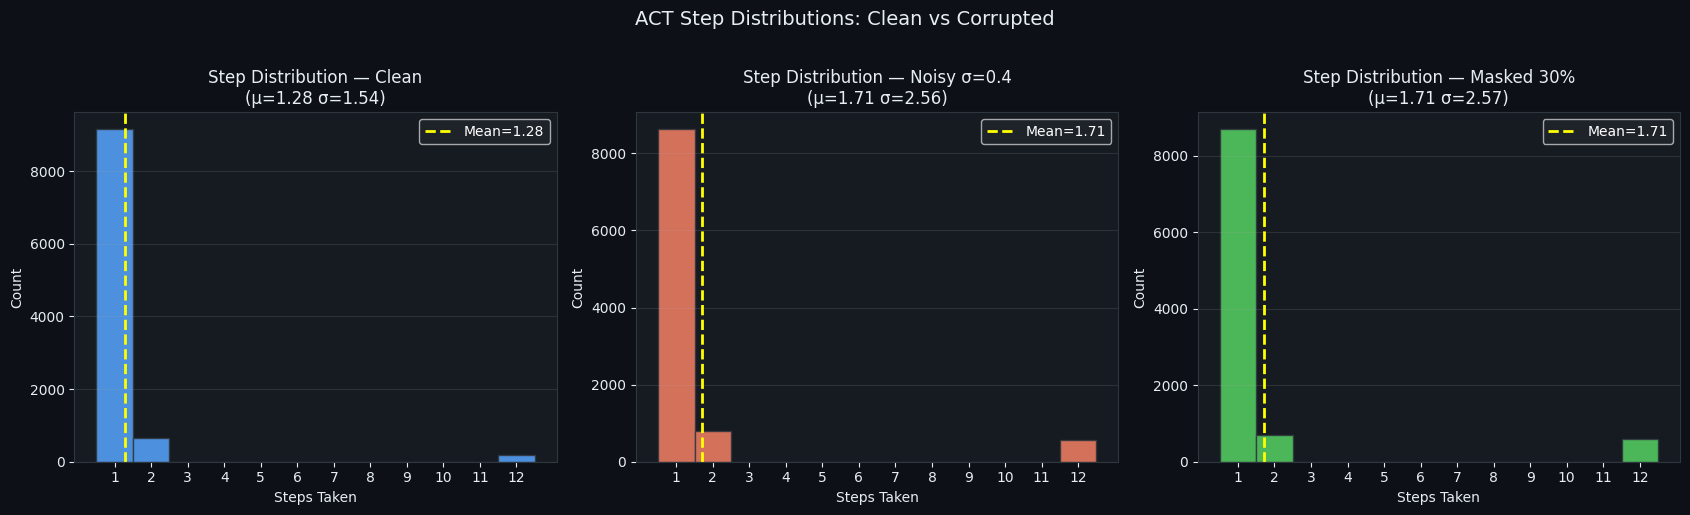

Saved: step_distribution.png

Step mean shift (clean→noisy): +0.432 steps
  → Positive = adaptive (harder inputs use more computation) ✓


In [36]:
@torch.no_grad()
def collect_steps(model, loader, corrupt_fn=None, *args):
    model.eval()
    all_steps = []
    for imgs, _ in loader:
        if corrupt_fn:
            imgs = corrupt_fn(imgs.to(DEVICE), *args)
        else:
            imgs = imgs.to(DEVICE)
        _, _, steps, _, _ = model(imgs)
        all_steps.extend(steps.cpu().tolist())
    return all_steps


steps_clean  = collect_steps(act_model, test_loader)
steps_noisy  = collect_steps(act_model, test_loader, add_gaussian_noise, 0.4)
steps_masked = collect_steps(act_model, test_loader, add_random_mask, MASK_FRACTION)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor('#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22'); ax.tick_params(colors='#e6edf3')
    ax.xaxis.label.set_color('#e6edf3'); ax.yaxis.label.set_color('#e6edf3')
    ax.title.set_color('#e6edf3')
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

bins = range(1, MAX_STEPS + 2)

for ax, steps_data, label, color in [
    (axes[0], steps_clean,  f'Clean\n(μ={np.mean(steps_clean):.2f} σ={np.std(steps_clean):.2f})',  '#58a6ff'),
    (axes[1], steps_noisy,  f'Noisy σ=0.4\n(μ={np.mean(steps_noisy):.2f} σ={np.std(steps_noisy):.2f})', '#f78166'),
    (axes[2], steps_masked, f'Masked 30%\n(μ={np.mean(steps_masked):.2f} σ={np.std(steps_masked):.2f})', '#56d364'),
]:
    ax.hist(steps_data, bins=bins, color=color, edgecolor='#30363d', alpha=0.85, align='left')
    ax.axvline(np.mean(steps_data), color='yellow', lw=2, linestyle='--', label=f'Mean={np.mean(steps_data):.2f}')
    ax.set_xlabel('Steps Taken'); ax.set_ylabel('Count')
    ax.set_title(f'Step Distribution — {label}')
    ax.legend(facecolor='#21262d', labelcolor='white')
    ax.set_xticks(range(1, MAX_STEPS + 1)); ax.grid(True, axis='y', alpha=0.15)

plt.suptitle('ACT Step Distributions: Clean vs Corrupted', color='#e6edf3', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('step_distribution.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

clean_mean, noisy_mean = np.mean(steps_clean), np.mean(steps_noisy)
print(f"Saved: step_distribution.png")
print(f"\nStep mean shift (clean→noisy): {noisy_mean - clean_mean:+.3f} steps")
print(f"  → Positive = adaptive (harder inputs use more computation) ✓" if noisy_mean > clean_mean
      else "  → ⚠ Non-adaptive: noisy inputs not using more steps")


Alpha Sensitivity Analysis

In [ ]:
ALPHAS       = [0.001, 0.01, 0.02, 0.05, 0.1, 0.2]
EPOCHS_SWEEP = 12     
alpha_results = []

for alpha in ALPHAS:
    model_a = ACTModel().to(DEVICE)
    opt_a   = optim.AdamW(model_a.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched_a = optim.lr_scheduler.CosineAnnealingLR(opt_a, T_max=EPOCHS_SWEEP)

    for epoch in range(1, EPOCHS_SWEEP + 1):
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_a.zero_grad()
            logits, ponder, _, _, per_step_logits = model_a(imgs)
            loss, _, _, _ = act_loss(logits, labels, ponder, per_step_logits,
                                     alpha=get_alpha(epoch) * (alpha / ALPHA))
            loss.backward()
            nn.utils.clip_grad_norm_(model_a.parameters(), 1.0)
            opt_a.step()
        sched_a.step()

    res = eval_act(model_a, test_loader)
    alpha_results.append((alpha, res['acc'], res['steps'], res['step_std']))
    print(f"α={alpha:.3f}  acc={res['acc']*100:.2f}%  avg_steps={res['steps']:.3f}  std={res['step_std']:.3f}")

fig, ax1 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d1117'); ax1.set_facecolor('#161b22')
ax2 = ax1.twinx()

alphas_x = [r[0] for r in alpha_results]
accs     = [r[1]*100 for r in alpha_results]
steps_y  = [r[2] for r in alpha_results]
stds_y   = [r[3] for r in alpha_results]

l1, = ax1.plot(alphas_x, accs,    'o-', color='#58a6ff', lw=2, ms=8, label='Accuracy (%)')
l2, = ax2.plot(alphas_x, steps_y, 's--', color='#f78166', lw=2, ms=8, label='Avg Steps')
l3, = ax2.plot(alphas_x, stds_y,  '^:', color='#56d364', lw=2, ms=8, label='Step Std')

for ax in (ax1, ax2):
    ax.tick_params(colors='#e6edf3')
    for spine in ax.spines.values(): spine.set_edgecolor('#30363d')

ax1.set_xlabel('Ponder Cost Weight α', color='#e6edf3')
ax1.set_ylabel('Test Accuracy (%)', color='#58a6ff')
ax2.set_ylabel('Steps / Std', color='#f78166')
ax1.set_xscale('log')
ax1.set_title('Alpha Sensitivity: Accuracy vs Compute Tradeoff', color='#e6edf3')
ax1.legend(handles=[l1, l2, l3], facecolor='#21262d', labelcolor='white', loc='center left')
ax1.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig('alpha_sensitivity.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Saved: alpha_sensitivity.png")


α=0.001  acc=92.56%  avg_steps=11.272  std=2.488
